# Classification Models

In this notebook, machine learning classification models are trained to predict the categorical stress level.

The target variable is `stress_category`, which has three classes:

- Low
- Medium
- High

The goal is to compare different classification models using accuracy, precision, recall, F1-score, and confusion matrix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Step 1: Loading the Processed Dataset

In this step, the processed dataset saved during preprocessing is loaded.

This dataset already contains encoded categorical variables, engineered features, and the classification target variable `stress_category`.

In [2]:
PROJECT_DIR = Path(r"C:\Users\onury\OneDrive\Masaüstü\Machine Learning\ML-Stress-Level-Prediction")

processed_path = PROJECT_DIR / "data" / "processed" / "processed_health_indicators.csv"

df = pd.read_csv(processed_path)

df.head()

,age,steps_per_day,active_minutes,sedentary_minutes,sleep_hours,sleep_quality,stress_level,workouts_per_week,diet_quality,hydration_liters,...,heart_rate_avg,consistency_score,lifestyle_category_Athlete,lifestyle_category_Sedentary,fitness_level_Moderate,fitness_level_Unfit,activity_ratio,sleep_deficit,heart_rate_difference,stress_category
0,56,12633,122,1084,8.65,8.67,4.42,2,5.61,2.14,...,103.0,3.84,False,False,True,False,0.101161,0.65,48.2,Medium
1,46,1980,33,1122,5.97,5.37,7.91,2,8.17,0.92,...,126.3,7.25,False,False,False,True,0.028571,2.03,51.1,High
2,32,7139,60,1049,6.23,7.15,4.20,0,3.47,2.67,...,101.4,5.77,False,True,False,True,0.054103,1.77,35.1,Medium
3,60,4814,66,1018,5.09,7.61,7.12,4,5.26,2.17,...,107.8,9.11,False,False,True,False,0.060886,2.91,43.2,High
4,25,8096,86,1031,5.49,5.57,3.88,3,2.60,2.91,...,92.8,7.55,False,False,True,False,0.076992,2.51,28.8,Low


In [3]:
print("Dataset shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print("-", col)

Dataset shape: (1000000, 22)

Columns:
- age
- steps_per_day
- active_minutes
- sedentary_minutes
- sleep_hours
- sleep_quality
- stress_level
- workouts_per_week
- diet_quality
- hydration_liters
- bmi
- heart_rate_resting
- heart_rate_avg
- consistency_score
- lifestyle_category_Athlete
- lifestyle_category_Sedentary
- fitness_level_Moderate
- fitness_level_Unfit
- activity_ratio
- sleep_deficit
- heart_rate_difference
- stress_category


# Step 2: Preparing Data for Classification

For the classification task, the target variable is `stress_category`.

The `stress_level` column is removed from the input features because `stress_category` was created from `stress_level`.

Both `stress_level` and `stress_category` are excluded from the input features to avoid data leakage.

In [4]:
X = df.drop(columns=["stress_level", "stress_category"])
y = df["stress_category"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("stress_level in X:", "stress_level" in X.columns)
print("stress_category in X:", "stress_category" in X.columns)

X shape: (1000000, 20)
y shape: (1000000,)
stress_level in X: False
stress_category in X: False


# Step 3: Target Class Distribution

Before model training, the distribution of the target classes is checked.

This helps us understand whether the classification problem is balanced or imbalanced.

In [5]:
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

Class counts:
stress_category
Medium    551876
High      318985
Low       129139
Name: count, dtype: int64

Class percentages:
stress_category
Medium    55.1876
High      31.8985
Low       12.9139
Name: proportion, dtype: float64


# Step 4: Train-Test Split

The classification dataset is split into training and testing sets.

80% of the data is used for training, and 20% is used for testing.

Since the class distribution is not perfectly balanced, stratified splitting is used to preserve the class proportions in both sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800000, 20)
X_test shape: (200000, 20)
y_train shape: (800000,)
y_test shape: (200000,)


## Interpretation of Classification Train-Test Split

The classification dataset was split into training and testing sets using an 80%-20% ratio.

The training set contains 800,000 records, while the testing set contains 200,000 records.

Both `stress_level` and `stress_category` were removed from the input features to avoid data leakage.

The dataset is now ready for classification model training.

In [7]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
stress_category
Medium    55.187625
High      31.898500
Low       12.913875
Name: proportion, dtype: float64

Testing target distribution:
stress_category
Medium    55.1875
High      31.8985
Low       12.9140
Name: proportion, dtype: float64


# Step 5: Logistic Regression Classifier

Logistic Regression is used as the baseline classification model.

Since Logistic Regression is sensitive to feature scales, StandardScaler is used before model training.

The model is evaluated using accuracy, precision, recall, and F1-score.

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [9]:
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, n_jobs=-1)
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, average="weighted", zero_division=0)
recall_logistic = recall_score(y_test, y_pred_logistic, average="weighted", zero_division=0)
f1_logistic = f1_score(y_test, y_pred_logistic, average="weighted", zero_division=0)

print("Logistic Regression Results")
print("Accuracy:", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall:", recall_logistic)
print("F1-score:", f1_logistic)

c:\Users\onury\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression Results
Accuracy: 0.718595
Precision: 0.7222473383238754
Recall: 0.718595
F1-score: 0.7108672952830856


In [10]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

        High       0.75      0.57      0.65     63797
         Low       0.72      0.53      0.61     25828
      Medium       0.71      0.85      0.77    110375

    accuracy                           0.72    200000
   macro avg       0.72      0.65      0.68    200000
weighted avg       0.72      0.72      0.71    200000



## Interpretation of Logistic Regression Results

Logistic Regression was used as the baseline classification model.

The model achieved an accuracy of approximately 71.86% and a weighted F1-score of approximately 0.71.

The classification report shows that the model performs best on the Medium stress class. The recall for the Medium class is approximately 0.85, meaning that most Medium stress samples were correctly identified.

However, the recall values for the Low and High stress classes are lower. This means that the model has more difficulty correctly identifying Low and High stress cases.

Overall, Logistic Regression provides a reasonable baseline, but more advanced models may improve the classification performance.

# Step 6: Decision Tree Classifier

Decision Tree Classifier is used as a non-linear classification model.

Unlike Logistic Regression, Decision Tree can capture non-linear relationships between the input features and the target classes.

In this experiment, `max_depth=10` is used to control model complexity and reduce overfitting.

In [11]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, average="weighted", zero_division=0)
recall_tree = recall_score(y_test, y_pred_tree, average="weighted", zero_division=0)
f1_tree = f1_score(y_test, y_pred_tree, average="weighted", zero_division=0)

print("Decision Tree Classifier Results")
print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)

Decision Tree Classifier Results
Accuracy: 0.75815
Precision: 0.7611066404841235
Recall: 0.75815
F1-score: 0.7527152787724702


In [12]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

        High       0.79      0.64      0.70     63797
         Low       0.76      0.57      0.65     25828
      Medium       0.75      0.87      0.80    110375

    accuracy                           0.76    200000
   macro avg       0.76      0.69      0.72    200000
weighted avg       0.76      0.76      0.75    200000



## Interpretation of Decision Tree Classifier Results

Decision Tree Classifier performed better than the baseline Logistic Regression model.

The accuracy increased from approximately 71.86% to 75.82%, and the weighted F1-score increased from approximately 0.71 to 0.75.

The classification report shows that the model performs best on the Medium stress class, with a recall value of approximately 0.87.

The recall values for the Low and High stress classes also improved compared to Logistic Regression, but they are still lower than the Medium class.

These results suggest that Decision Tree Classifier can capture non-linear relationships better than Logistic Regression.

# Step 7: Initial Classification Model Comparison

In this step, the baseline Logistic Regression model and the Decision Tree Classifier are compared using accuracy, precision, recall, and F1-score.

In [13]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree Classifier"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree
    ],
    "Precision": [
        precision_logistic,
        precision_tree
    ],
    "Recall": [
        recall_logistic,
        recall_tree
    ],
    "F1-score": [
        f1_logistic,
        f1_tree
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.718595,0.722247,0.718595,0.710867
1,Decision Tree Classifier,0.758150,0.761107,0.758150,0.752715


## Interpretation of Initial Classification Comparison

The initial comparison shows that Decision Tree Classifier performs better than Logistic Regression on all evaluation metrics.

Decision Tree achieved higher accuracy, precision, recall, and F1-score.

This suggests that the classification problem contains non-linear patterns that are better captured by tree-based models.

# Step 8: Random Forest Classifier

Random Forest Classifier is an ensemble learning model that combines multiple decision trees.

It generally provides more stable and accurate predictions than a single Decision Tree.

Since the dataset is large, a sample of 100,000 training records is used to reduce training time.

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
X_train_rf_sample = X_train.sample(n=100000, random_state=42)
y_train_rf_sample = y_train.loc[X_train_rf_sample.index]

print("Random Forest training sample shape:", X_train_rf_sample.shape)
print("Random Forest target sample shape:", y_train_rf_sample.shape)

Random Forest training sample shape: (100000, 20)
Random Forest target sample shape: (100000,)


In [16]:
random_forest_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_rf_sample, y_train_rf_sample)

y_pred_rf = random_forest_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

print("Random Forest Classifier Results")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Random Forest Classifier Results
Accuracy: 0.75457
Precision: 0.765301870428001
Recall: 0.75457
F1-score: 0.746040400082329


In [17]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        High       0.83      0.59      0.69     63797
         Low       0.77      0.54      0.64     25828
      Medium       0.73      0.90      0.80    110375

    accuracy                           0.75    200000
   macro avg       0.78      0.68      0.71    200000
weighted avg       0.77      0.75      0.75    200000



## Interpretation of Random Forest Classifier Results

Random Forest Classifier achieved an accuracy of approximately 75.46% and a weighted F1-score of approximately 0.75.

The model performed similarly to the Decision Tree Classifier, but it did not outperform it in this experiment.

One possible reason is that Random Forest was trained on a sample of 100,000 training records instead of the full training set in order to reduce training time.

The classification report shows that the model performs best on the Medium stress class. The recall for the Medium class is approximately 0.90, while the recall values for Low and High stress classes are lower.

Overall, Random Forest provides competitive results, but Decision Tree remains slightly better based on the current metrics.

In [19]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree Classifier",
        "Random Forest Classifier"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf
    ],
    "F1-score": [
        f1_logistic,
        f1_tree,
        f1_rf
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.718595,0.722247,0.718595,0.710867
1,Decision Tree Classifier,0.758150,0.761107,0.758150,0.752715
2,Random Forest Classifier,0.754570,0.765302,0.754570,0.746040


# Step 9: Gradient Boosting Classifier

Gradient Boosting Classifier is an ensemble learning model that builds models sequentially.

Each new model tries to correct the errors made by the previous models.

In this notebook, `HistGradientBoostingClassifier` is used because it is efficient for large tabular datasets.

In [20]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [21]:
gradient_boosting_model = HistGradientBoostingClassifier(
    max_iter=100,
    max_leaf_nodes=31,
    learning_rate=0.1,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average="weighted", zero_division=0)
recall_gb = recall_score(y_test, y_pred_gb, average="weighted", zero_division=0)
f1_gb = f1_score(y_test, y_pred_gb, average="weighted", zero_division=0)

print("Gradient Boosting Classifier Results")
print("Accuracy:", accuracy_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1-score:", f1_gb)

Gradient Boosting Classifier Results
Accuracy: 0.768025
Precision: 0.7702638397034822
Recall: 0.768025
F1-score: 0.7635883482779837


In [22]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

        High       0.80      0.66      0.72     63797
         Low       0.75      0.59      0.66     25828
      Medium       0.76      0.87      0.81    110375

    accuracy                           0.77    200000
   macro avg       0.77      0.71      0.73    200000
weighted avg       0.77      0.77      0.76    200000



## Interpretation of Gradient Boosting Classifier Results

Gradient Boosting Classifier achieved the best classification performance among the tested models.

The model achieved an accuracy of approximately 76.80% and a weighted F1-score of approximately 0.76.

The classification report shows that the model performs best on the Medium stress class, with a recall value of approximately 0.87.

Compared to Logistic Regression, Decision Tree, and Random Forest, Gradient Boosting provides the best overall balance between accuracy, precision, recall, and F1-score.

These results suggest that ensemble-based models are more effective for this classification task because they can capture complex and non-linear relationships in the dataset.

# Step 10: Final Classification Model Comparison

In this step, all classification models are compared using accuracy, precision, recall, and F1-score.

The tested models are:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier

In [23]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree Classifier",
        "Random Forest Classifier",
        "Gradient Boosting Classifier"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf,
        accuracy_gb
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf,
        precision_gb
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf,
        recall_gb
    ],
    "F1-score": [
        f1_logistic,
        f1_tree,
        f1_rf,
        f1_gb
    ]
})

classification_results = classification_results.sort_values(by="F1-score", ascending=False)

classification_results

,Model,Accuracy,Precision,Recall,F1-score
3,Gradient Boosting Classifier,0.768025,0.770264,0.768025,0.763588
1,Decision Tree Classifier,0.758150,0.761107,0.758150,0.752715
2,Random Forest Classifier,0.754570,0.765302,0.754570,0.746040
0,Logistic Regression,0.718595,0.722247,0.718595,0.710867


## Interpretation of Final Classification Model Comparison

The final classification comparison shows that Gradient Boosting Classifier achieved the best overall performance.

It has the highest accuracy and weighted F1-score among the tested models.

Logistic Regression performed the weakest, which suggests that the relationship between the input features and stress categories is not purely linear.

Decision Tree and Random Forest performed better than Logistic Regression because they can capture non-linear patterns.

Gradient Boosting achieved the best result because it builds models sequentially and improves predictions by correcting previous errors.

Based on these results, Gradient Boosting Classifier is selected as the best classification model.

# Step 11: Visualizing Classification Model Performance

In this step, the classification model results are visualized to compare model performance more clearly.

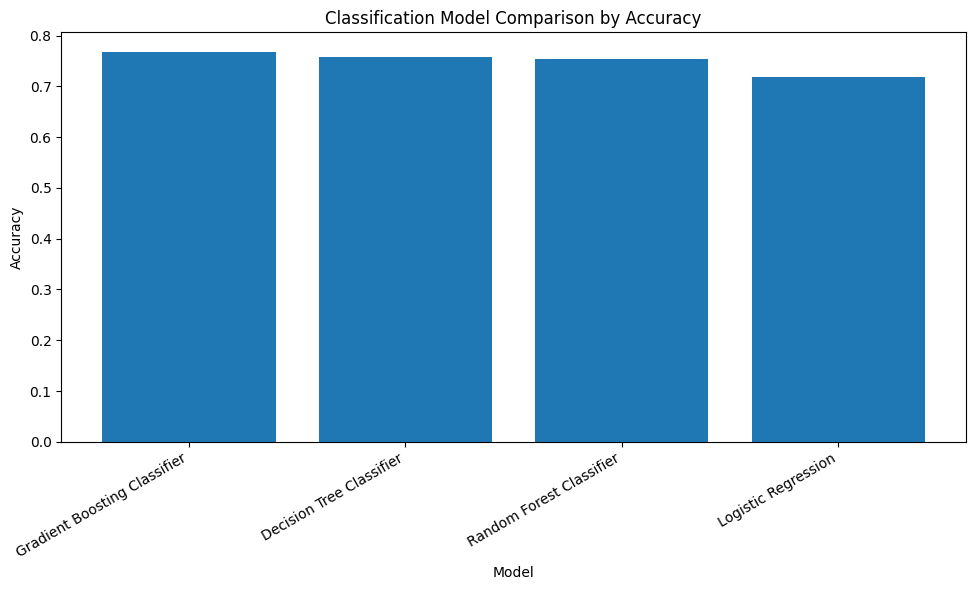

In [24]:
plt.figure(figsize=(10, 6))

plt.bar(classification_results["Model"], classification_results["Accuracy"])

plt.title("Classification Model Comparison by Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

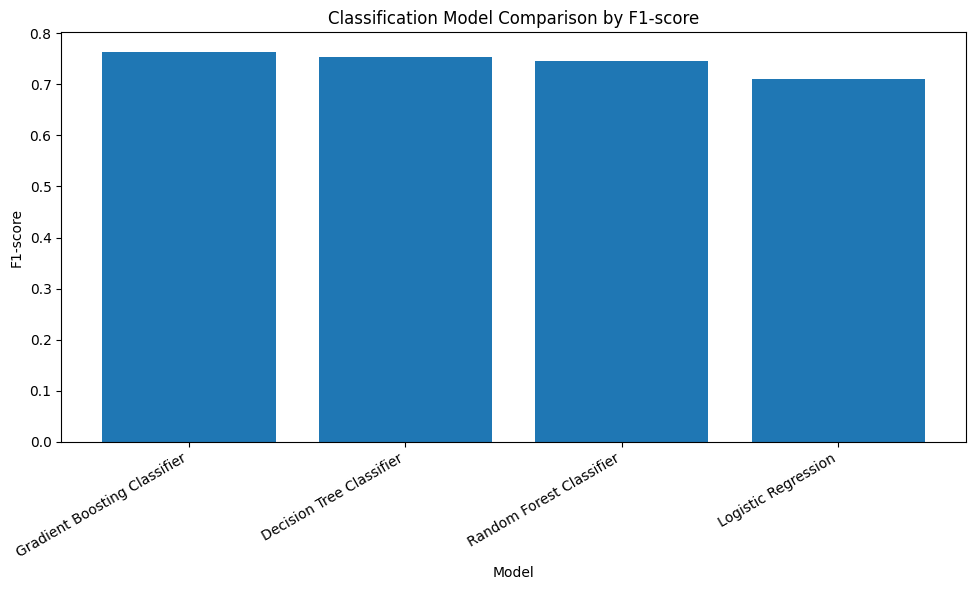

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(classification_results["Model"], classification_results["F1-score"])

plt.title("Classification Model Comparison by F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## Interpretation of Classification Performance Visualizations

The accuracy chart shows that Gradient Boosting Classifier achieved the highest classification accuracy.

The F1-score chart also shows that Gradient Boosting Classifier produced the best balance between precision and recall.

Logistic Regression had the weakest performance, while tree-based and ensemble-based models performed better.

Overall, the visual comparison confirms that Gradient Boosting Classifier is the best classification model among the tested models.

# Step 12: Confusion Matrix for the Best Classification Model

In this step, a confusion matrix is created for the best classification model.

Gradient Boosting Classifier is used because it achieved the best classification performance.

In [26]:
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, y_pred_gb, labels=labels)

cm

array([[15337,  9333,  1158],
       [ 4879, 96195,  9301],
       [  246, 21478, 42073]])

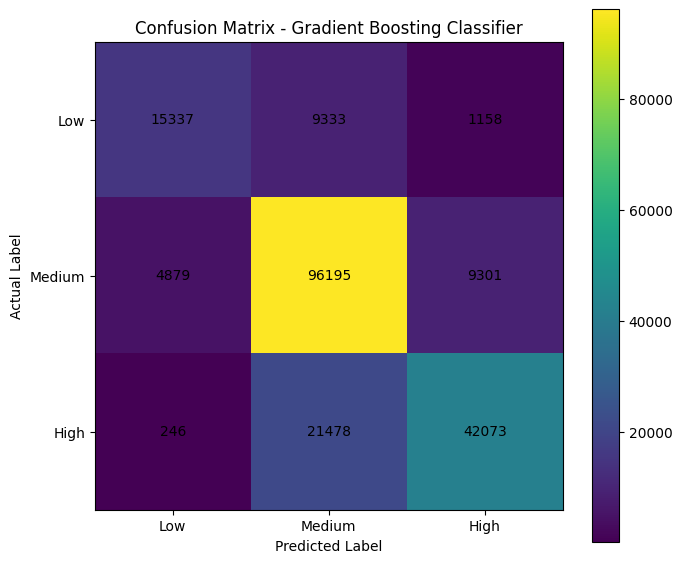

In [27]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)
plt.colorbar()

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

plt.title("Confusion Matrix - Gradient Boosting Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Interpretation of Confusion Matrix

The confusion matrix shows how the Gradient Boosting Classifier predicted each stress category.

The model correctly classified 15,337 Low stress samples, 96,195 Medium stress samples, and 42,073 High stress samples.

The best performance is observed for the Medium stress class. This is expected because Medium is the largest class in the dataset.

The model sometimes confuses Low and High stress samples with Medium stress. For example, 9,333 Low stress samples were predicted as Medium, and 21,478 High stress samples were predicted as Medium.

This shows that the model has a tendency to predict the Medium class more often, which may be related to the class distribution of the dataset.

Overall, the confusion matrix supports the classification report and confirms that Gradient Boosting Classifier performs best on the Medium stress class.

# Step 13: Saving Classification Results

The classification model comparison results are saved as a CSV file for later use in the report and presentation.

In [28]:
results_path = PROJECT_DIR / "reports"
results_path.mkdir(parents=True, exist_ok=True)

classification_results.to_csv(results_path / "classification_model_results.csv", index=False)

print("Classification results saved successfully.")

Classification results saved successfully.


# Step 14: Classification Modeling Summary

In this notebook, four classification models were trained and evaluated to predict the categorical `stress_category` variable.

The tested models were:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier

The models were evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

Logistic Regression was used as the baseline classification model. It achieved the weakest performance among the tested models.

Decision Tree and Random Forest performed better than Logistic Regression because they can capture non-linear relationships in the dataset.

Gradient Boosting Classifier achieved the best overall classification performance, with the highest accuracy and weighted F1-score.

The confusion matrix showed that the model performs best on the Medium stress class. Low and High stress samples are sometimes confused with Medium stress.

Based on the results, Gradient Boosting Classifier was selected as the best classification model.